Implementation of Ridge Regression.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

NumPy version: 2.0.2
Pandas version: 2.2.2


In [ ]:
def load_process_data(filename):

  df = pd.read_csv(filename)
  x_raw = df['X'].values
  y_raw = df['Y'].values
  std_dev = df['Standard Deviation'].values

  ones = np.ones(x_raw.shape[0])
  X_matrix = np.column_stack((ones, x_raw)) # adding a column of ones for the Beta_not
  Y_vector = y_raw.reshape(-1,1) # ensuring y is a column vector

  weights = 1.0/(std_dev**2)

  W_matrix = np.diag(weights)

  return X_matrix, Y_vector, W_matrix, df


In [ ]:
X_train, Y_train, W_train, df_train = load_process_data("train_data.csv")
X_test, Y_test, W_test, df_test = load_process_data("test_data.csv")
print(" Training Data Shapes ")
print(f"X_train: {X_train.shape} ") # should be 100, 2
print(f"Y_train: {Y_train.shape} ") # should be 100, 1
print(f"W_train: {W_train.shape} ") # should be 100, 100

print("\n Test Data Shapes ")
print(f"X_test: {X_test.shape}") #should be 40, 2
print(f"Y_test: {Y_test.shape}") #should be 40, 1
print(f"W_test: {W_test.shape}") #should be 40, 40

print("\n First 5x5 block of W_train ") # to confirm whether diagonal
print(W_train[:5, :5])

 Training Data Shapes 
X_train: (100, 2) 
Y_train: (100, 1) 
W_train: (100, 100) 

 Test Data Shapes 
X_test: (40, 2)
Y_test: (40, 1)
W_test: (40, 40)

 First 5x5 block of W_train 
[[2314.99161414    0.            0.            0.            0.        ]
 [   0.         1971.36184204    0.            0.            0.        ]
 [   0.            0.         2089.5330349     0.            0.        ]
 [   0.            0.            0.         2166.10244898    0.        ]
 [   0.            0.            0.            0.         2458.5113882 ]]


Note: W_test has no significance as it will not be used. The use of a common function for processing both the datasets leads to its existence.

In [ ]:
def fit_ols(X, Y):
    """
    Computes OLS coefficients using the closed-form solution.
    Beta = (X^T X)^-1 X^T Y
    """
    # 1. Compute X Transpose
    Xt = X.T

    # 2. Compute X^T * X
    XtX = Xt @ X

    # 3. Compute X^T * Y
    XtY = Xt @ Y

    # 4. Compute Inverse and multiply: (XtX)^-1 @ XtY
    # Note: In production code, np.linalg.solve is numerically more stable,
    # but for this assignment, explicit inverse is expected to show the formula.
    beta_ols = np.linalg.inv(XtX) @ XtY

    return beta_ols

def fit_wls(X, Y, W):
    """
    Computes WLS coefficients using the closed-form solution.
    Beta = (X^T W X)^-1 X^T W Y
    """
    # 1. Compute X Transpose
    Xt = X.T

    # 2. Compute X^T * W * X
    XtWX = Xt @ W @ X

    # 3. Compute X^T * W * Y
    XtWY = Xt @ W @ Y

    # 4. Compute Inverse and multiply
    beta_wls = np.linalg.inv(XtWX) @ XtWY

    return beta_wls

In [ ]:
beta_ols = fit_ols(X_train, Y_train)
beta_wls = fit_wls(X_train, Y_train, W_train)
print("Learned Parameters (Coefficients)")
print("Format: [[Intercept], [Slope]]\n")

print(f"OLS Beta:\n{beta_ols}")
print(f"WLS Beta:\n{beta_wls}")


Learned Parameters (Coefficients)
Format: [[Intercept], [Slope]]

OLS Beta:
[[0.09733629]
 [0.36473142]]
WLS Beta:
[[0.1005584 ]
 [0.34866922]]


We have the parameters. Now to calculate the predictions and residuals for both OLS and WLS.

In [ ]:
#Training Predictions
y_hat_ols_train = X_train @ beta_ols
y_hat_wls_train = X_train @ beta_wls

#Testing Predictions
y_hat_ols_test = X_test @ beta_ols
y_hat_wls_test = X_test @ beta_wls

#Training residuals
resid_ols_train = Y_train - y_hat_ols_train
resid_wls_train = Y_train - y_hat_wls_train

#Testing residuals
resid_ols_test = Y_test - y_hat_ols_test
resid_wls_test = Y_test - y_hat_wls_test

In [ ]:
def calculate_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

mse_ols_train = calculate_mse(Y_train, y_hat_ols_train)
mse_wls_train = calculate_mse(Y_train, y_hat_wls_train)
mse_ols_test = calculate_mse(Y_test, y_hat_ols_test)
mse_wls_test = calculate_mse(Y_test, y_hat_wls_test)

print(f"MSE OLS (Train): {mse_ols_train:.10f}")
print(f"MSE WLS (Train): {mse_wls_train:.10f}")
print(f"MSE OLS (Test): {mse_ols_test:.6f}")
print(f"MSE WLS (Test): {mse_wls_test:.6f}")

MSE OLS (Train): 0.0003706457
MSE WLS (Train): 0.0003708160
MSE OLS (Test): 0.000770
MSE WLS (Test): 0.000780


Plot Residuals vs Input

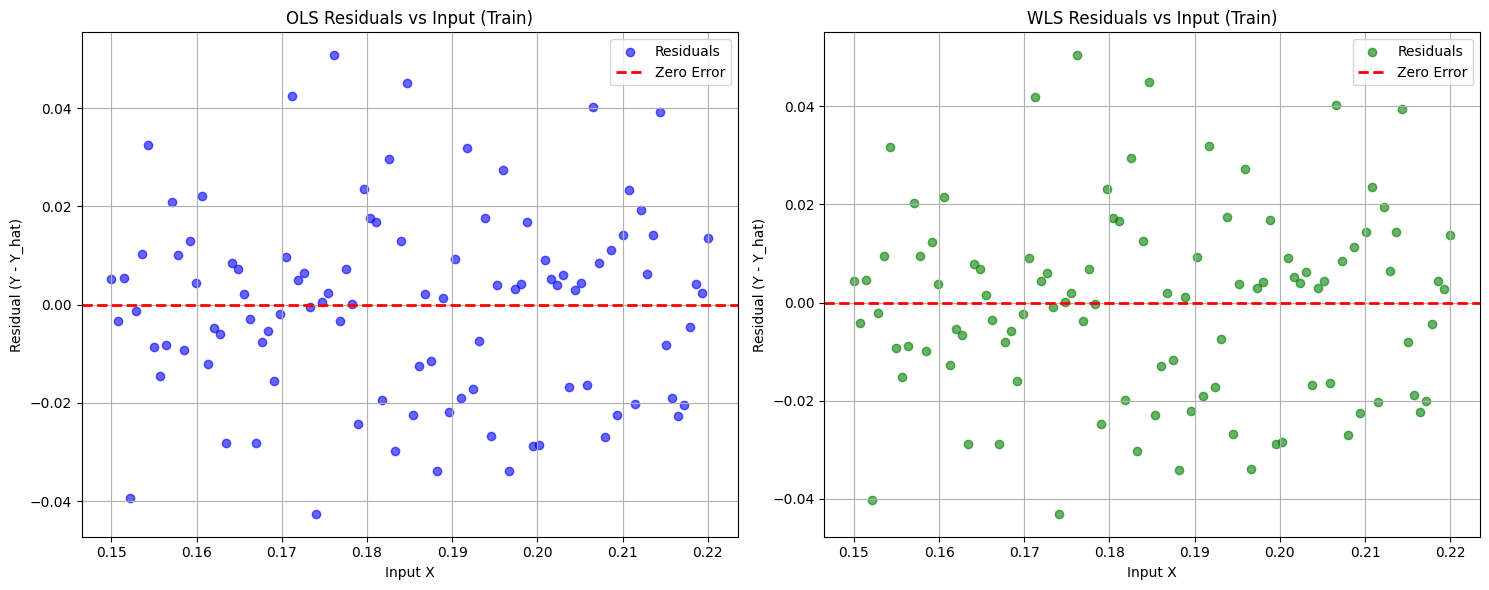

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))

x_vals_train = X_train[:,1] # taking only second column of the X matrix.

#Plot 1 - OLS
axes[0].scatter(x_vals_train, resid_ols_train, color='blue', alpha=0.6, label='Residuals')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0].set_title('OLS Residuals vs Input (Train)')
axes[0].set_xlabel('Input X')
axes[0].set_ylabel('Residual (Y - Y_hat)')
axes[0].legend()
axes[0].grid(True)

#Plot 2 - WLS
axes[1].scatter(x_vals_train, resid_wls_train, color='green', alpha=0.6, label='Residuals')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].set_title('WLS Residuals vs Input (Train)')
axes[1].set_xlabel('Input X')
axes[1].set_ylabel('Residual (Y - Y_hat)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

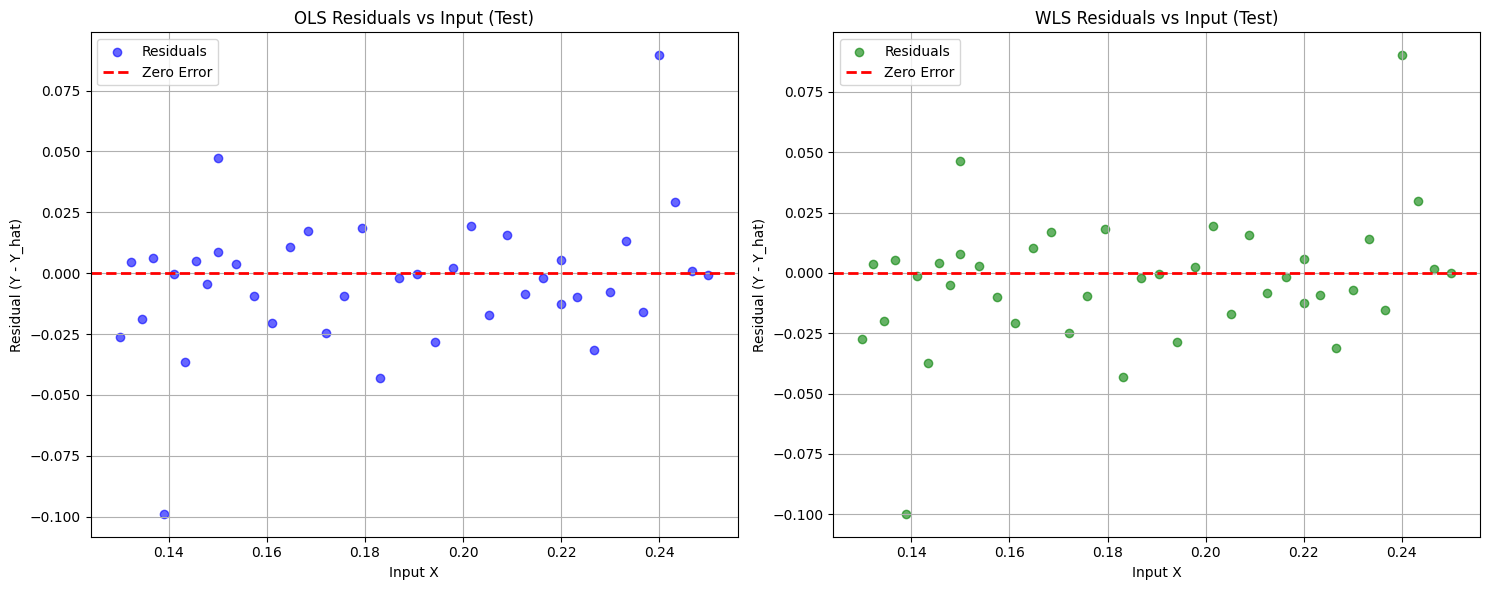

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))

x_vals_test = X_test[:,1] # taking only second column of the X matrix.

#Plot 1 - OLS test
axes[0].scatter(x_vals_test, resid_ols_test, color='blue', alpha=0.6, label='Residuals')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0].set_title('OLS Residuals vs Input (Test)')
axes[0].set_xlabel('Input X')
axes[0].set_ylabel('Residual (Y - Y_hat)')
axes[0].legend()
axes[0].grid(True)

#Plot 2 - WLS test
axes[1].scatter(x_vals_test, resid_wls_test, color='green', alpha=0.6, label='Residuals')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].set_title('WLS Residuals vs Input (Test)')
axes[1].set_xlabel('Input X')
axes[1].set_ylabel('Residual (Y - Y_hat)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Predicted v/s Expected output for WLS and OLS

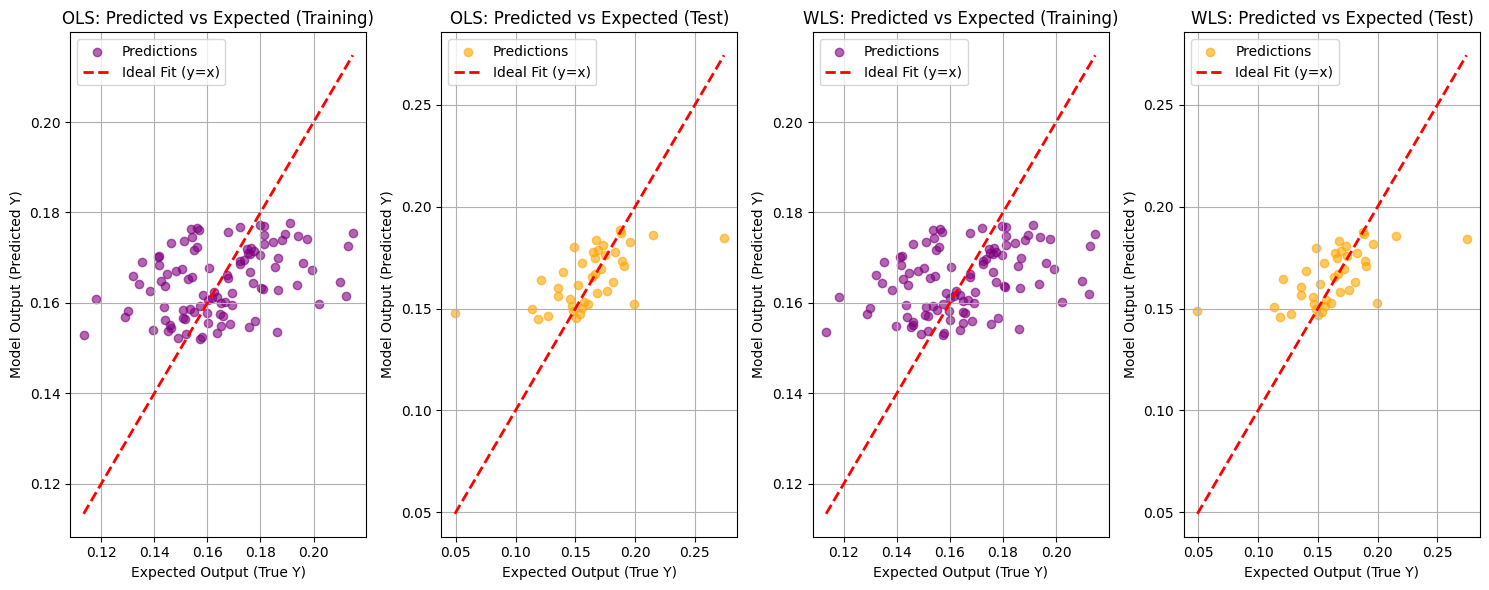

In [ ]:
fig, axes = plt.subplots(1,4, figsize=(15,6))

#Plot 1 - Training
# X-axis: Expected (True Y)
# Y-axis: Predicted (Model Output)
axes[0].scatter(Y_train, y_hat_ols_train, color='purple', alpha=0.6, label='Predictions')

# Add the ideal 45-degree line
min_val = min(Y_train.min(), y_hat_ols_train.min())
max_val = max(Y_train.max(), y_hat_ols_train.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Fit (y=x)')

axes[0].set_title('OLS: Predicted vs Expected (Training)')
axes[0].set_xlabel('Expected Output (True Y)')
axes[0].set_ylabel('Model Output (Predicted Y)')
axes[0].legend()
axes[0].grid(True)

#Plot 2 - Test
axes[1].scatter(Y_test, y_hat_ols_test, color='orange', alpha=0.6, label='Predictions')

# Add the ideal 45-degree line
min_val_test = min(Y_test.min(), y_hat_ols_test.min())
max_val_test = max(Y_test.max(), y_hat_ols_test.max())
axes[1].plot([min_val_test, max_val_test], [min_val_test, max_val_test], 'r--', linewidth=2, label='Ideal Fit (y=x)')

axes[1].set_title('OLS: Predicted vs Expected (Test)')
axes[1].set_xlabel('Expected Output (True Y)')
axes[1].set_ylabel('Model Output (Predicted Y)')
axes[1].legend()
axes[1].grid(True)

#Plot 1 - Training
# X-axis: Expected (True Y)
# Y-axis: Predicted (Model Output)
axes[2].scatter(Y_train, y_hat_wls_train, color='purple', alpha=0.6, label='Predictions')

# Add the ideal 45-degree line
min_val = min(Y_train.min(), y_hat_wls_train.min())
max_val = max(Y_train.max(), y_hat_wls_train.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Fit (y=x)')

axes[2].set_title('WLS: Predicted vs Expected (Training)')
axes[2].set_xlabel('Expected Output (True Y)')
axes[2].set_ylabel('Model Output (Predicted Y)')
axes[2].legend()
axes[2].grid(True)

#Plot 2 - Test
axes[3].scatter(Y_test, y_hat_wls_test, color='orange', alpha=0.6, label='Predictions')

# Add the ideal 45-degree line
min_val_test = min(Y_test.min(), y_hat_wls_test.min())
max_val_test = max(Y_test.max(), y_hat_wls_test.max())
axes[3].plot([min_val_test, max_val_test], [min_val_test, max_val_test], 'r--', linewidth=2, label='Ideal Fit (y=x)')

axes[3].set_title('WLS: Predicted vs Expected (Test)')
axes[3].set_xlabel('Expected Output (True Y)')
axes[3].set_ylabel('Model Output (Predicted Y)')
axes[3].legend()
axes[3].grid(True)

plt.tight_layout()
plt.show()

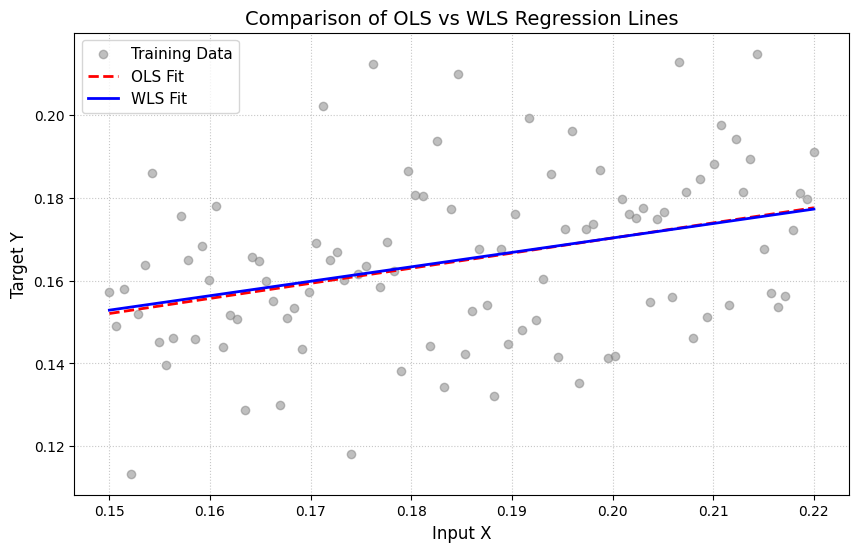

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define a smooth range of X values for plotting the lines
#    We go from slightly below min(X) to slightly above max(X)
x_min = X_train[:, 1].min()
x_max = X_train[:, 1].max()
x_range = np.linspace(x_min, x_max, 100)

# 2. Create a design matrix for this range (Add column of 1s)
#    Shape: (100, 2)
X_line = np.column_stack((np.ones(x_range.shape), x_range))

# 3. Calculate the Y values for the lines using learned Betas
y_line_ols = X_line @ beta_ols
y_line_wls = X_line @ beta_wls

# 4. Plotting
plt.figure(figsize=(10, 6))

# A. Scatter plot of the actual training data
#    We use 'alpha' to make points transparent so we can see overlapping data
plt.scatter(X_train[:, 1], Y_train, color='gray', alpha=0.5, label='Training Data')

# B. Plot OLS Line (Red Dashed)
plt.plot(x_range, y_line_ols, color='red', linestyle='--', linewidth=2, label='OLS Fit')

# C. Plot WLS Line (Blue Solid)
plt.plot(x_range, y_line_wls, color='blue', linestyle='-', linewidth=2, label='WLS Fit')

# D. Formatting
plt.title('Comparison of OLS vs WLS Regression Lines', fontsize=14)
plt.xlabel('Input X', fontsize=12)
plt.ylabel('Target Y', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

# Show the plot
plt.show()

<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1287/1889097079.py:25: SyntaxWarning: invalid escape sequence '\s'
  ecolor='lightgray', elinewidth=2, capsize=3, alpha=0.6, label='Data (with $\sigma$)')


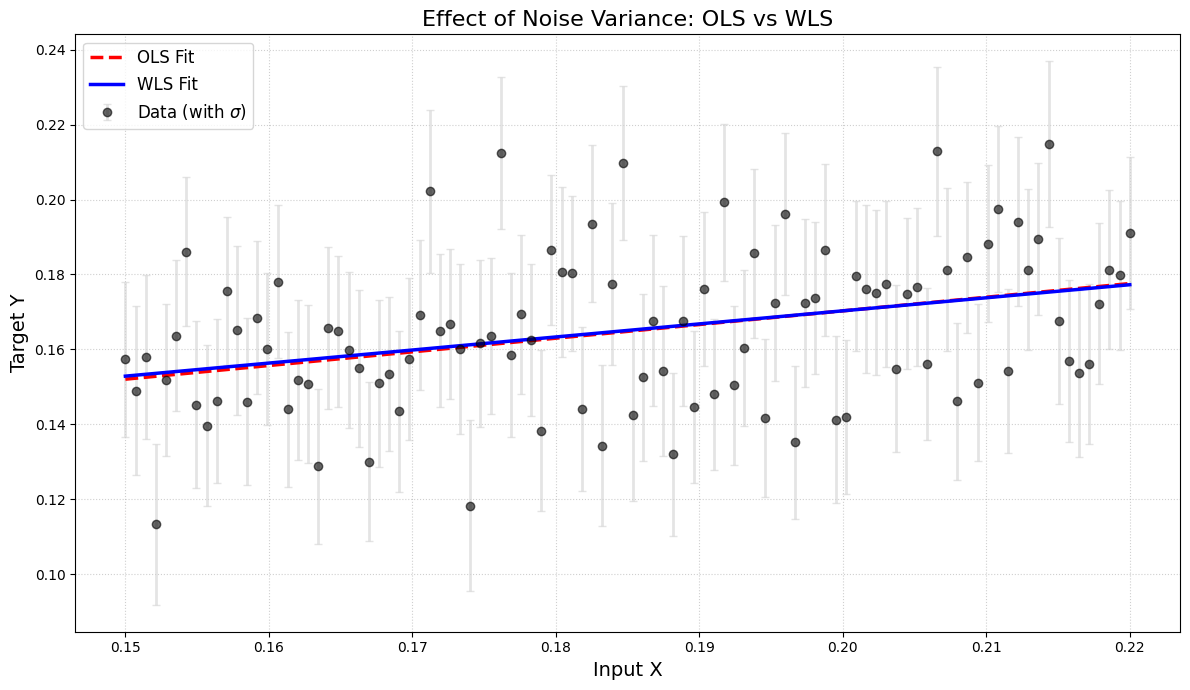

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare Data for Plotting
x_data = X_train[:, 1]
y_data = Y_train.flatten() # Flatten to 1D array for plotting
y_err = df_train['Standard Deviation'].values # This is our noise (sigma)

# 2. Prepare Regression Lines (Smooth lines)
x_range = np.linspace(x_data.min(), x_data.max(), 100)
X_line = np.column_stack((np.ones(x_range.shape), x_range))

y_ols_line = X_line @ beta_ols
y_wls_line = X_line @ beta_wls

# 3. Create the Plot
plt.figure(figsize=(12, 7))

# --- A. Plot Data with Error Bars ---
# fmt='o': Plot points as circles
# ecolor='gray': Color of the error bars
# capsize=3: Adds little caps to the error bars
# alpha=0.5: Transparency
plt.errorbar(x_data, y_data, yerr=y_err, fmt='o', color='black',
             ecolor='lightgray', elinewidth=2, capsize=3, alpha=0.6, label='Data (with $\sigma$)')

# --- B. Plot OLS Line (Red Dashed) ---
plt.plot(x_range, y_ols_line, color='red', linestyle='--', linewidth=2.5, label='OLS Fit')

# --- C. Plot WLS Line (Blue Solid) ---
plt.plot(x_range, y_wls_line, color='blue', linestyle='-', linewidth=2.5, label='WLS Fit')

# 4. Formatting
plt.title('Effect of Noise Variance: OLS vs WLS', fontsize=16)
plt.xlabel('Input X', fontsize=14)
plt.ylabel('Target Y', fontsize=14)
plt.legend(fontsize=12, loc='best')
plt.grid(True, linestyle=':', alpha=0.6)

# Show plot
plt.tight_layout()
plt.show()